### Carregando a base

In [2]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

# Carregando o dataset de luxo sustentável
# Certifique-se de que o arquivo está na mesma pasta do seu script
df = pd.read_excel('Sustainable_Luxury_Survey_500.xlsx')

# Visualizando as primeiras linhas e as colunas (Big Five, Atitudes, etc.)
print(df.head())

# Verificando os tipos de dados para garantir que as escalas são numéricas
print(df.info())

   Respondent_ID  O1  O2  O3  O4  O5  O6  O7  O8  O9  ...  \
0              1   4   4   4   4   3   4   2   3   3  ...   
1              2   4   4   4   5   5   4   2   4   2  ...   
2              3   4   5   4   5   5   5   1   5   2  ...   
3              4   4   4   3   3   5   3   3   4   2  ...   
4              5   5   3   4   4   4   4   2   5   2  ...   

   Chanel_Sustainability  Chanel_Prestige  Openness_Score  \
0                      2                4             3.7   
1                      3                5             4.2   
2                      3                5             4.7   
3                      4                4             3.7   
4                      3                3             4.1   

   Conscientiousness_Score  Extraversion_Score  Agreeableness_Score  \
0                 3.777778               3.875                4.125   
1                 4.000000               2.875                4.000   
2                 4.444444               4.000       

In [4]:
print(df.shape)

(500, 75)


In [5]:
print(df.columns)
print(df.dtypes)

Index(['Respondent_ID', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9',
       'O10', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'E1', 'E2',
       'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6',
       'A7', 'A8', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9',
       'Age_Group', 'Gender', 'Income_Level', 'Region', 'ATT1', 'ATT2', 'ATT3',
       'ATT4', 'ATT5', 'PI1', 'PI2', 'MD1', 'MD2', 'MD3',
       'StellaMcCartney_Sustainability', 'StellaMcCartney_Prestige',
       'Gucci_Sustainability', 'Gucci_Prestige', 'Fendi_Sustainability',
       'Fendi_Prestige', 'Chanel_Sustainability', 'Chanel_Prestige',
       'Openness_Score', 'Conscientiousness_Score', 'Extraversion_Score',
       'Agreeableness_Score', 'Neuroticism_Score',
       'Sustainability_Attitude_Score', 'Purchase_Intention_Score',
       'Motivational_Drivers_Score'],
      dtype='str')
Respondent_ID                      int64
O1                                 int64
O2       

### Verificando Dados nulos

In [6]:
import pandas as pd

# 1. Carregar a sua base
df = pd.read_excel('Sustainable_Luxury_Survey_500.xlsx') # Ajuste o nome se for .xlsx

# 2. Mostrar a contagem de nulos por coluna
print("Quantidade de valores nulos em cada coluna:")
print(df.isnull().sum())

# 3. Resumo total (para o seu relatório)
total_nulos = df.isnull().sum().sum()
print(f"\nTotal de dados nulos na base inteira: {total_nulos}")

Quantidade de valores nulos em cada coluna:
Respondent_ID                    0
O1                               0
O2                               0
O3                               0
O4                               0
                                ..
Agreeableness_Score              0
Neuroticism_Score                0
Sustainability_Attitude_Score    0
Purchase_Intention_Score         0
Motivational_Drivers_Score       0
Length: 75, dtype: int64

Total de dados nulos na base inteira: 0


### Definir os dados_numericos (Limpando ID e Age)

In [7]:
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
colunas_para_analise = [c for c in colunas_numericas if c not in ['ID', 'Age']]
dados_numericos = df[colunas_para_analise]

## Matriz de Correlação

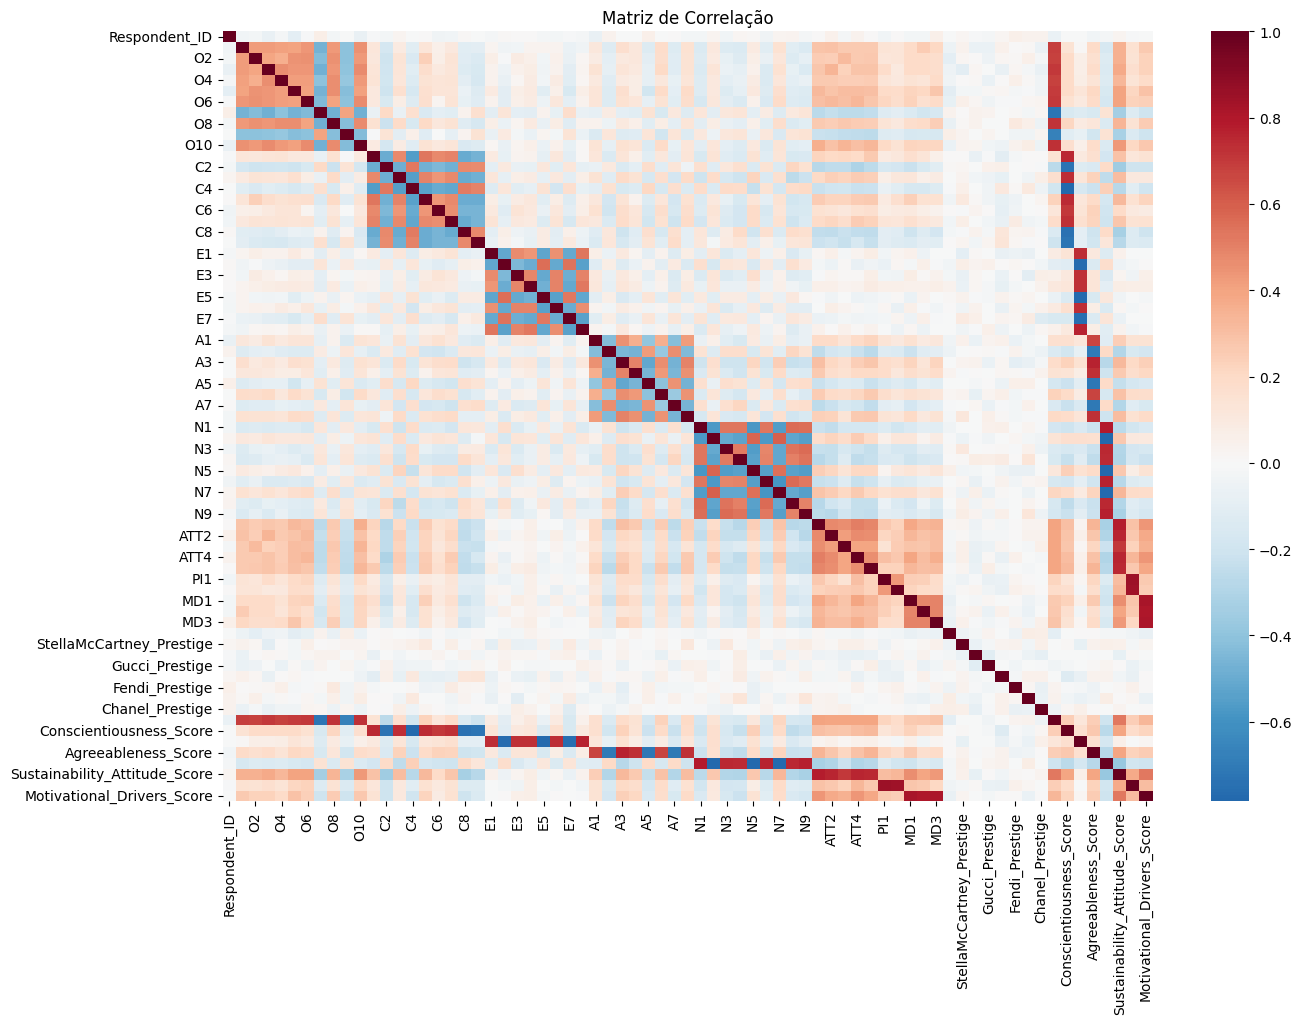

In [8]:
# 1. Selecionar apenas as colunas de percepção/atitude
# Selecionar as colunas numéricas que não são Age ou ID
colunas_para_analise = df.select_dtypes(include=['float64', 'int64']).columns
colunas_para_analise = [c for c in colunas_para_analise if c not in ['Age', 'ID']] # removemos o que não é atitude

df_analise = df[colunas_para_analise]

# 2. Gerar a Matriz de Correlação
matriz_corr = df_analise.corr()

# 3. Criar o Heatmap (Mapa de Calor)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(matriz_corr, annot=False, cmap='RdBu_r', center=0)
plt.title('Matriz de Correlação')
plt.show()

### Extração de Fatores (Sessão 06 - Eigenvalues e Scree Plot)

In [9]:
pip install factor_analyzer

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcular a matriz de correlação 
corr_matrix = dados_finais.corr()

# 2. Calcular os Eigenvalues (Valores Próprios) usando Numpy
# Isso evita o erro do 'force_all_finite'
eigenvalues = np.linalg.eigvals(corr_matrix)
eigenvalues = sorted(eigenvalues, reverse=True) # Colocar em ordem do maior para o menor

# 3. Gerar o Scree Plot (Gráfico de Sedimentação)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', color='blue')
plt.axhline(y=1, color='red', linestyle='--') # Linha de corte do Slide (Eigenvalue > 1)
plt.title('Scree Plot (Gráfico de Sedimentação) - Sessão 06')
plt.xlabel('Número de Fatores')
plt.ylabel('Eigenvalue (Valor Próprio)')
plt.grid()
plt.show()

# 4. Mostrar os valores exatos
print("Eigenvalues (Valores Próprios):")
for i, valor in enumerate(eigenvalues[:10]):
    print(f"Fator {i+1}: {valor:.3f}")

NameError: name 'dados_finais' is not defined

### Rotação Varimax

In [ ]:
from sklearn.decomposition import FactorAnalysis
import pandas as pd

from sklearn.decomposition import FactorAnalysis
import pandas as pd

# 1. Garantir que o ID não interfira
dados_para_analise = dados_finais.drop(columns=['Respondent_ID'], errors='ignore')

# 2. Configurar para os 10 fatores que o seu Scree Plot indicou
# Usando a Rotação Varimax conforme a Sessão 06
fa_10 = FactorAnalysis(n_components=10, rotation='varimax')
fa_10.fit(dados_para_analise)

# 3. Criar a tabela de cargas fatoriais
loadings_10 = pd.DataFrame(
    fa_10.components_.T,
    index=dados_para_analise.columns,
    columns=[f'F1', f'F2', f'F3', f'F4', f'F5', f'F6', f'F7', f'F8', f'F9', f'F10']
)

# 4. Limpar para ver apenas cargas > 0.3
loadings_10_clean = loadings_10.map(lambda x: round(x, 3) if abs(x) > 0.3 else "")

# 5. Comando para MOSTRAR TUDO (sem os pontinhos ...)
pd.set_option('display.max_rows', None)
print("--- Matriz de Cargas Fatoriais (10 Fatores - VARIMAX) ---")
print(loadings_10_clean)

--- Matriz de Cargas Fatoriais (10 Fatores - VARIMAX) ---
                                   F1     F2     F3     F4     F5     F6  \
O1                                                                         
O2                                                                         
O3                                                                         
O4                                                                         
O5                                                                         
O6                                                                         
O7                                                                         
O8                                                                         
O9                                                                         
O10                                                                        
C1                                                                -0.675   
C2                            